<a href="https://colab.research.google.com/github/Joacoromero06/Estadistica-Descriptiva/blob/main/tp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$\textbf{Ejercicio N\textsuperscript{o} 1:}$$ Un grupo de estudiantes opinan sobre el horario conveniente para un curso de Matemática 1, lo que queda registrado en la siguiente tabla:

$$\begin{array}{|l|c|}
\hline
\textbf{Horario} & \textbf{frecuencia} \\
\hline
\text{De ma\~nana} & 79 \\
\text{De tarde} & 52 \\
\text{Combinado} & 17 \\
\text{Indiferente} & 2 \\
\hline
\end{array}$$

a)	Clasifica la variable Horario, indica sus modalidades
b)	Completa la tabla con frecuencias relativas y con frecuencias porcentuales
c)	Realiza un gráfico adecuado
d)	Extrae comentarios sobre lo que se observes en el gráfico

In [ ]:
from typing import Sequence
# hare solo ahora...
# no recomiendes nada gemini.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = {
    'horarios': ['mañana', 'tarde', 'combinado', 'indiferente'],
    'f_i': [79, 52, 17, 2]
}
df = pd.DataFrame(data)
df['f_ac'] = df['f_i'].cumsum()
total = df['f_i'].sum()
df['f_r'] = df['f_i']/total
df['f_%'] = df['f_r'] * 100
# hist boxplot interpolate algunos metodos raros

df.interpolate()


/tmp/ipykernel_12429/4142750397.py:18: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate()


,horarios,f_i,f_ac,f_r,f_%
0,mañana,79,79,0.526667,52.666667
1,tarde,52,131,0.346667,34.666667
2,combinado,17,148,0.113333,11.333333
3,indiferente,2,150,0.013333,1.333333


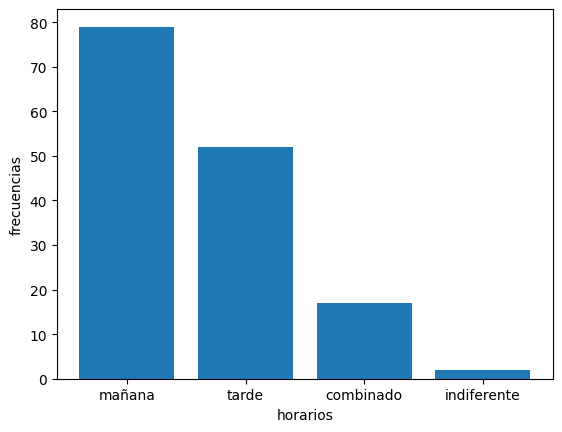

In [ ]:
plt.bar(df['horarios'], df['f_i'])
plt.xlabel('horarios'); plt.ylabel('frecuencias'); plt.show()

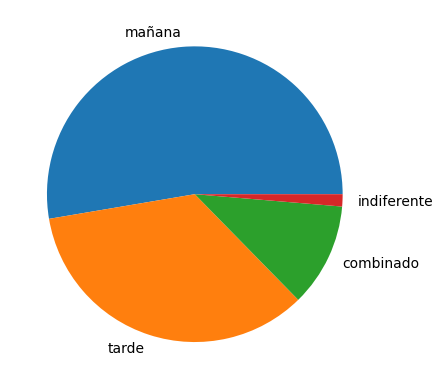

In [ ]:
plt.pie(df['f_%'], labels=df['horarios'].tolist())
plt.show()

<Axes: xlabel='horarios'>

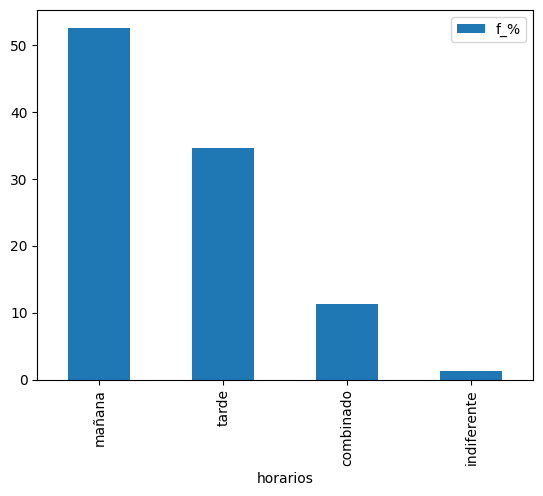

In [ ]:
df.plot.bar(x='horarios', y='f_%')

## Ejercicio Nº 2:
20 chicos registran la cantidad de mascotas que desearían tener en la siguiente tabla:

| N° de mascotas | frecuencia |
|----------------|------------|
| 0              | 4          |
| 1              | 6          |
| 2              | 5          |
| 3              | 3          |
| 4              | 3          |
| 5              | 1          |

a) Clasifica la variable N° de mascotas, indica sus modalidades
b) Completa la tabla con frecuencias relativas y con frecuencias acumuladas
c) Realiza los gráficos adecuados
d) ¿Cuántos chicos desean tener a lo sumo 2 mascotas?
e) ¿Cuántos chicos desean tener al menos 3 mascotas?
f) Extrae comentarios sobre lo que se observes en el gráfico

## Ejercicio Nº 3:

El departamento de atención al cliente de un importante cadena de restaurantes advierte que muchos clientes se quejan por la atención inadecuada de por parte del servicios de mozos. Para analizar las causas del problema se decide realizar una encuesta anónima a 125 clientes para que indiquen cuáles son las quejas con respecto a la atención de los mozos. Los resultados fueron los siguientes:

*   a) 4 personas se quejaron por la falta de predisposición de los mozos.
*   b) 15 por estar pendiente del celular.
*   c) 9 por malos modales al recibir los pedidos.
*   d) 20 por lenguaje inadecuado.
*   e) 50 por no detallar los platos sugeridos.
*   f) 27 por mozos conversando.

Para tomar decisiones encaminadas a solucionar las quejas frecuentes, realizar un Diagrama de Pareto para determinar cuáles son las mejoras más urgentes para mejorar el servicio de mozos.

In [ ]:
data = {
    'numero de mascotas': [i for i in range(6)],
    'f_i': [4, 6, 5, 3, 3, 1]
}
df = pd.DataFrame(data)
N = df['f_i'].sum()
df['f_ac'] = df['f_i'].cumsum()
df['f_r'] = df['f_i'] / N
df['f_%'] = df['f_r'] * 100
df.interpolate()

,numero de mascotas,f_i,f_ac,f_r,f_%
0,0,4,4,0.181818,18.181818
1,1,6,10,0.272727,27.272727
2,2,5,15,0.227273,22.727273
3,3,3,18,0.136364,13.636364
4,4,3,21,0.136364,13.636364
5,5,1,22,0.045455,4.545455


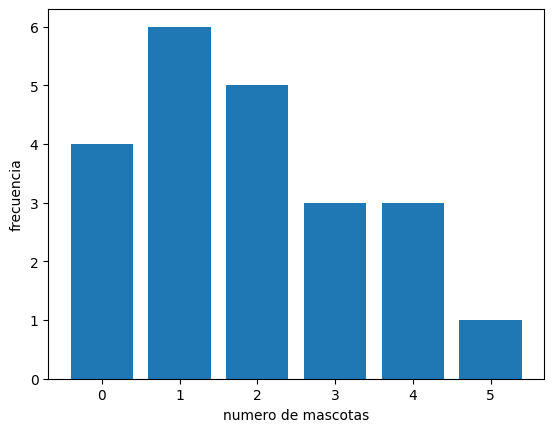

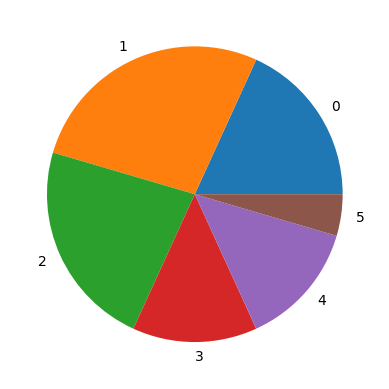

In [ ]:
plt.bar(df['numero de mascotas'], df['f_i'])
plt.xlabel('numero de mascotas'); plt.ylabel('frecuencia'); plt.show()
plt.pie(df['f_%'], labels=df['numero de mascotas'].tolist())
plt.show()

In [ ]:
def media_variables_discretas(df: pd.DataFrame, clave_variable, clave_frecuencia):
    xs = df[clave_variable]
    fs = df[clave_frecuencia]
    media, n = 0, 0
    for x, f in zip(xs, fs):
        n += f
        media += x*f
    return media / n, n

if __name__ == '__main__':
    mu, n = media_variables_discretas(df, 'numero de mascotas', 'f_i')

In [ ]:
def mediana_var_ordXtabla_freq(df: pd.DataFrame, clave_variable, clave_frecuencia_acumulada, N):
    fs = list(df[clave_frecuencia_acumulada])
    i = 0
    while i < len(fs) and fs[i] < N/2:
        i+=1
    if i == len(fs):
        return -1
    else:
        return df[clave_variable][i]

_, n = media_variables_discretas(df, 'numero de mascotas', 'f_i')
mediana_var_ordXtabla_freq(df, 'numero de mascotas', 'f_ac', n)

np.int64(2)

In [ ]:
def cuartil_var_ordXtabla_freq(k , N, df, clave_variable, clave_frecuencia_acumulada):
    if k < 0 or k > 4:
        print(f'error no se puede obtener el cuartil numero {k}')

    fs = list(df[clave_frecuencia_acumulada])
    frecuencia_buscada = N * k/4; print(f'frecuencia buscada: {frecuencia_buscada}')

    i = 0
    while i < len(fs) and fs[i] < frecuencia_buscada:
        i += 1
    if i == len(fs)-1:
        return -1
    else:
        return df[clave_variable][i]

if __name__ == '__main__':
    _, n = media_variables_discretas(df, 'numero de mascotas', 'f_i')
    cuartil_k = cuartil_var_ordXtabla_freq(3, n, df, 'numero de mascotas', 'f_ac')
    print(cuartil_k)
df.interpolate()


frecuencia buscada: 16.5
3


,numero de mascotas,f_i,f_ac,f_r,f_%
0,0,4,4,0.181818,18.181818
1,1,6,10,0.272727,27.272727
2,2,5,15,0.227273,22.727273
3,3,3,18,0.136364,13.636364
4,4,3,21,0.136364,13.636364
5,5,1,22,0.045455,4.545455


Ejercicio Nº3: El departamento de atención al cliente de un importante cadena de restaurantes advierte que
muchos cliente se quejan por la atención inadecuada de por parte del servicios de mozos.
Para analizar las causas del problema se decide realizar una encuesta anónima a 125 clientes para que
indiquen cuales son las quejas con respecto a la atención de los mozos. Los resultados fueron los siguientes:
a) 4 personas se quejaron la falta de predisposición de los mozos, b) 15 por estar pendiente del celular, c) 9
malos modales al recibir los pedidos, d) 20 por lenguaje inadecuado, e) 50 por no detallar los platos sugerido
y f) 27 mozos conversando.
Para tomar decisiones encaminadas a solucionar las quejas frecuentes, realizar un Diagrama de Pareto para
determinar cuáles son las mejoras más urgentes para mejorar el servicio de mozos.

In [ ]:
quejas = ["no hay predisposicion", "uso de celular", "malos modales", "lenguaje inapropiado", "no detalla los platos", "conversan"]
datos = {
    "Queja": quejas,
    "f_i": [4, 15, 9, 20, 50, 21]
}
df = pd.DataFrame(datos)
df = df.sort_values('f_i', ascending=False).reset_index(drop=True)
df["f_ac"] = df["f_i"].cumsum()
N = df['f_i'].sum()
df['f_r'] = df['f_i'] / N
df['f_%'] = df['f_r'] * 100
df['f_%_ac'] = df['f_%'].cumsum()
df.interpolate()

/tmp/ipykernel_12429/1263864435.py:13: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate()


,Queja,f_i,f_ac,f_r,f_%,f_%_ac
0,no detalla los platos,50,50,0.420168,42.016807,42.016807
1,conversan,21,71,0.176471,17.647059,59.663866
2,lenguaje inapropiado,20,91,0.168067,16.806723,76.470588
3,uso de celular,15,106,0.126050,12.605042,89.075630
4,malos modales,9,115,0.075630,7.563025,96.638655
5,no hay predisposicion,4,119,0.033613,3.361345,100.000000


(0.0, 100.0)

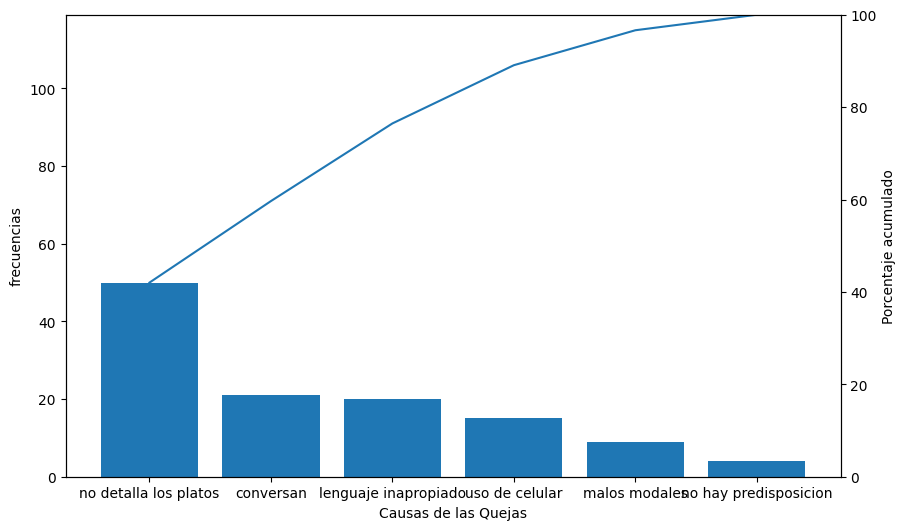

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.bar(df['Queja'], df['f_i']); ax1.set_xlabel('Causas de las Quejas'); ax1.set_ylabel('frecuencias'); ax1.set_ylim(0,N)
ax2 = ax1.twinx()
ax2.plot(df['Queja'], df['f_%_ac']); ax2.set_ylabel('Porcentaje acumulado'); ax2.set_ylim(0,100)

In [ ]:
# datos de 50 personas
tiempos = [
    70, 71, 62, 63, 67, 65, 75, 62, 65, 56,
    47, 68, 60, 54, 63, 60, 69, 54, 73, 55,
    57, 55, 55, 57, 59, 74, 56, 59, 71, 50,
    52, 63, 65, 50, 53, 59, 45, 72, 64, 69,
    51, 50, 60, 56, 67, 59, 68, 61, 51, 64
]
n = len(tiempos)
tiempos_min = min(tiempos)
tiempos_max = max(tiempos)
print('len de tiempos', len(tiempos))
print('tpo min:', min(tiempos))
print('tpo max:', max(tiempos))

len de tiempos 50
tpo min: 45
tpo max: 75


In [ ]:
limite_inferior = 45
amplitud = 5

bins = list(range(limite_inferior, 85, amplitud))
intervalos = [bins[i] + amplitud/2 for i in range(len(bins)-1)]
frecuencia, _ = np.histogram(tiempos, bins=bins)
N = frecuencia.sum()
frecuencia_relativa = frecuencia / N
frecuencia_relativa_acumulada = frecuencia_relativa.cumsum()
#frecuencia_porcentual = frecuencia_relativa * 100
#frecuencia_porcentual_acumulada = frecuencia_porcentual.cumsum()
def mostrar_tabla():
    print(frecuencia)
    print(frecuencia_relativa)
   #print(frecuencia_acumulada)
    #print(frecuencia_porcentual)
    #print(frecuencia_porcentual_acumulada)
mostrar_tabla()
print(intervalos)

[ 2  9 12 11  9  6  1]
[0.04 0.18 0.24 0.22 0.18 0.12 0.02]
[47.5, 52.5, 57.5, 62.5, 67.5, 72.5, 77.5]


In [ ]:
datos = {
    'Intervalos': intervalos,
    #'Marca de Clase': marcas_clase,
    'Frecuencia. (fi)': frecuencia,
    'Frecuencia Relativa. (fr)': frecuencia_relativa,
    'Frecuencia Relativa Acumulada. (fr ac)': frecuencia_relativa_acumulada,
    #'Frecuencia Porcencual. (f%)': frecuencia_porcentual,
    #'Frecuencia Porcentual Acumulada (f%ac)': frecuencia_porcentual_acumulada
}
df = pd.DataFrame(datos)
df.interpolate()

,Intervalos,Frecuencia. (fi),Frecuencia Relativa. (fr),Frecuencia Relativa Acumulada. (fr ac)
0,47.5,2,0.04,0.04
1,52.5,9,0.18,0.22
2,57.5,12,0.24,0.46
3,62.5,11,0.22,0.68
4,67.5,9,0.18,0.86
5,72.5,6,0.12,0.98
6,77.5,1,0.02,1.00


In [ ]:
def media_variables_continuas(df, clave_frecuencia, clave_variable):
    fs, xs = df[clave_frecuencia], df[clave_variable]
    n, s = 0, 0
    for mc, f in zip(xs, fs):
        n += f
        s += mc*f
    return s/n, n

if __name__ == '__main__':
    print(media_variables_continuas(df, 'Frecuencia. (fi)', 'Intervalos'))

(61.3, 50)


In [ ]:
def interpolacion_AE(f_sig, f, a_sig, a, N, k, partes):
    """
    N: cantidad de datos
    k: nro de partes buscadas
    partes: cuantas partes se dividen los datos
    """
    if partes > N:
        print(f'Error la cantidad de partes en la que se dividen los datos {partes} es mayor que la cantidad de datos {N}')
    if k > partes:
        print(f'Error el nro partes buscadas {k} es mayor que la cantidad de partes en la que se dividieron los datos {partes}')
    return ( (a_sig - a) / (f_sig - f) ) * (N* k/partes - f)


def frecuencia_acumulada_to_intervalo(f_buscada, frecuencias_acumuladas):
    i = 0
    i_inf, i_sup = -1,-1
    while i < len(frecuencias_acumuladas) and frecuencias_acumuladas[i] < f_buscada:
        i += 1
    if i == len(frecuencias_acumuladas):
        print(f'Error la frecuencia buscada es mayor que las frecuencias con estos datos')
    else:
        i_inf, i_sup = i-1, i
    return i_inf, i_sup

def percentil_to_valor(k, extremos, frecuencias_acumuladas):
    """   Determina el valor que separa los datos en k/100 y 1- k/100    """
    if k < 0 or k > 100:
        print(f'Error no existe percentil nro {k} debe estar entre 0 y 100')
    N = frecuencias_acumuladas[len(frecuencias_acumuladas)-1]
    frecuencia_buscada = N * k/100
    inf, sup = frecuencia_acumulada_to_intervalo(frecuencia_buscada, frecuencias_acumuladas)

    f, f_sig = frecuencias_acumuladas[inf], frecuencias_acumuladas[sup]
    a, a_sig = extremos[inf], extremos[sup]
    x = interpolacion_AE(f_sig, f, a_sig, a, N, k, 100)
    a_valor = a + x
    print(f'El valor de la variable que divide los datos en {(N*k/100)/N*100}% correspondiente a {N*k/100} datos es: {a_valor}')
    return a_valor

In [ ]:
def get_extremosYfrecuencia_acumulada(df):
    return bins, df['Frecuencia Relativa Acumulada. (fr ac)']

In [ ]:
extremos, frecuencias_acumuladas = get_extremosYfrecuencia_acumulada(df)
print(extremos, frecuencias_acumuladas)
percentil_to_valor(25, extremos, frecuencias_acumuladas)

Error la cantidad de partes en la que se dividen los datos 100 es mayor que la cantidad de datos 0.9999999999999999
El valor de la variable que divide los datos en 25.0% correspondiente a 0.24999999999999997 datos es: 50.625


np.float64(50.625)

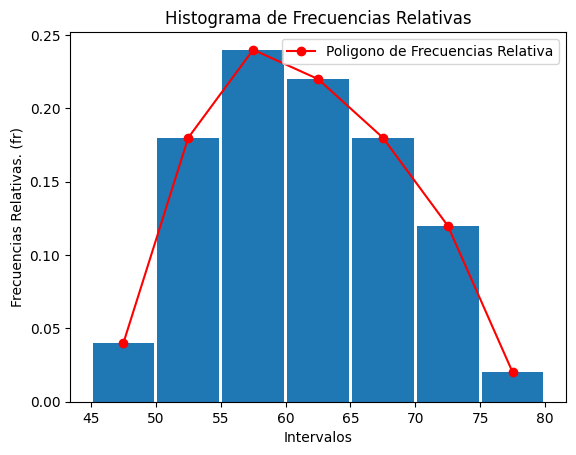

In [ ]:
fig1, ax1 = plt.subplots()
ax1.bar(df['Intervalos'], df['Frecuencia Relativa. (fr)'], width=amplitud*0.95)
ax1.plot(df['Intervalos'], df['Frecuencia Relativa. (fr)'], color='red', marker='o', label='Poligono de Frecuencias Relativa')
ax1.set_xlabel('Intervalos'); ax1.set_ylabel('Frecuencias Relativas. (fr)'); ax1.set_title('Histograma de Frecuencias Relativas')
ax1.legend()

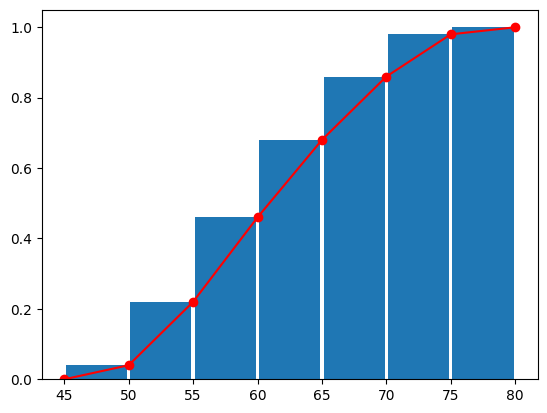

In [ ]:
fig2, ax2 = plt.subplots()
ax2.bar(df['Intervalos'], df['Frecuencia Relativa Acumulada. (fr ac)'], width=amplitud*0.95)
ojiva_x = [bins[0]]
ojiva_y = [0]
for i in range(len(bins)-1):
    ojiva_x.append(bins[i+1])
    ojiva_y.append(df['Frecuencia Relativa Acumulada. (fr ac)'][i])
ax2.plot(ojiva_x, ojiva_y, color='red', marker='o')